## Executive summary
Analysis of the FDA drug enforcement recall database from 2006 to 2026. 
KPI in the analysis:
Sterility accounts for 35.4% of recalls, representing the dominant cause.
Class II represent the majority of recalls
A linear regression on the 2012-2026 period shows a decreasing trend of -91.8 recalls/year.
The majority of recalls are initiated by firms and are in Class II. the compounding firms recall has Class I/II, instead the manufacturer firms has Class I/II/III recalls

## Analytical plan - FDA Drug Recall Analysis
### KPI 1 - Recall Distribution by Class and Cause
   - Classification distribution (Class I/II/III)
   - Divide reason_for_recall in macro categories
   - Cross-tabulation classification x cause

### KPI 2 - Regulatory response Timing
   - Days between recall_initiation_date and center_classification_date
   - Recalls distribution for Class
   - % voluntary vs mandated

### KPI 3 - Temporal Trends
   - Annual Recall Counts
   - Classification Trend during time

### KPI 4 - Top recalling firms
   - Major recall industries
   - Severity distribution for Class

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [ ]:
# Importazione Dataset
df = pd.read_csv('../data/02_fda_data_clean.csv', index_col = False)

In [29]:
# Ripristino date in datetime
date = [col for col in df.columns if col.endswith('date')]
for col in date:
    df[col] = pd.to_datetime(df[col])

## KPI 1 - Recall Distribution by Class and Cause
### Classification distribution ( Class I/II/III)
The FDA pharmaceutical recall are classified by cause and severity. Based on the recall cause each observation has a classification that depend on the non-conformity and the risk for the population that receive the drug. 
In this phase of the analysis we attribute to each observation a macro category based on the recall cause. 
Then we divide each category by classification.

In [30]:
# Creo delle categorie per reason_for_recall
def categorizza_recall(testo):
    t = testo.lower()
    if 'sterili' in t:
        return 'Sterility'
    elif any(parola in t for parola in ["adverse reaction", "adverse event"]):
        return 'Adverse Event'
    elif any(parola in t for parola in ['particulate', 'contaminat', 'foreign']):
        return 'Contamination'
    elif any(parola in t for parola in [ "potency", "strength", "assay", "below label", "subpotent drug", "superpotent"]):
        return 'Potency'
    elif any(parola in t for parola in ["failed specification", "failed test", "failed dissolution", "failed impurit", "impurit", "degradation", "dissolution", "precipitat", "discolor", "out of spec", "failed tablet", "failed capsule", "failed stability", "broken tablet"]):
        return 'Analytical Failure'
    elif any(parola in t for parola in ["without an approved", "marketed without"]):
        return 'Regulatory'
    elif any(parola in t for parola in ["cgmp", "gmp", "manufacturing practice", "processing control", "processing control", "insanitary"]):
        return 'CGMP'
    elif any(parola in t for parola in [ "container", "packaging", "package", "blister", "leak"]):
        return 'Packaging'
    elif any(parola in t for parola in ["label", "expir", "lot number"]):
        return 'Labeling'
    elif any(parola in t for parola in ["temperature", "refrigerat", "storage"]):
        return 'Storage'
    else:
        return 'Other'

df['recall_category'] = df['reason_for_recall'].apply(categorizza_recall)
df_clean = df[df['classification'] != 'Not Yet Classified']

#### NOTE: reason_for_recall categorization
Method: For the classification is attributed a hierarchy to each record to assign the major severity in case of multiple reason
CLASSIFICATION 
1. Sterility
2. Adverse Event
3. Contamination
4. Potency
5. Analytical Failure
6. Regulatory
7. CGMP
8. Packaging
9. Labeling
10. Storage
11. Other

Limit: Some categories, like 'Storage', are underrepresented because record with multiple causes are assigned to the worst cause. 
    Example: 'temperature abuse during sterile manufacturing' is classified as 'Sterility'.

584 records contain 'temperature' and 48 are classified as 'Storage' that is acceptable for this analysis. 
Future improvement: add a 'storage_flag' column for cross analysis


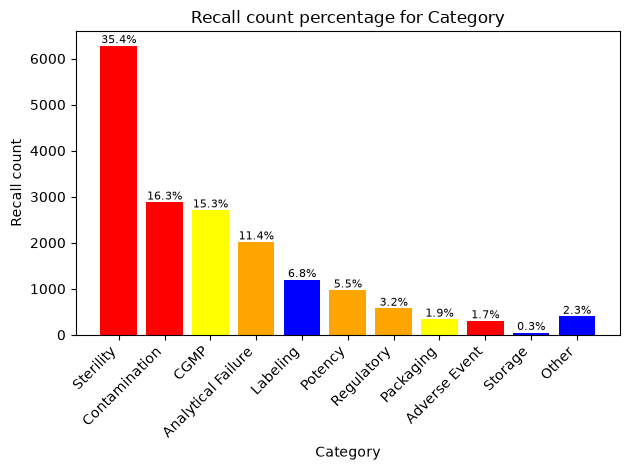

In [31]:
# Sposto 'Other' in fondo al grafico
counts = df_clean['recall_category'].value_counts()
if 'Other' in counts.index:
    other = counts.loc[['Other']]
    counts = counts.drop('Other')
    counts = pd.concat([counts, other])
# Definisco dei colori per il grafico in base ad una gerarchia
colori = {
    'Sterility': 'red',
    'Adverse Event': 'red',
    'Contamination': 'red',
    'Potency': 'orange',
    'Analytical Failure': 'orange',
    'Regulatory': 'orange',
    'CGMP': 'yellow',
    'Packaging': 'yellow',
    'Labeling': 'blue',
    'Storage': 'blue',
    'Other': 'blue'
    }

bar_colors = [colori.get(cat, 'gray') for cat in counts.index]
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values, color = bar_colors)
ax.set(xlabel = 'Category', 
       ylabel = 'Recall count', 
       title = 'Recall count percentage for Category')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

totale = len(df_clean)
for bar in bars:
    altezza = bar.get_height()
    percentuale = altezza/totale*100
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posizione X centrata
        altezza,                              # posizione Y
        f'{percentuale:.1f}%',               # testo
        ha='center', va='bottom', fontsize=8
    )


**Insights**

The majority of recalls are attributed to Sterility problems (35.4%) followed by contamination (16.3%). 
This indicates that that the majority of the drug recalling is caused by errors in the production phases, lack of sterility and contamination can be correlated in case of biological contamination. 
In fact, the biological contamination is a lack of sterility consequence. 
Chemical contamination can be caused by other sources.

### Recall reasons divided by Category

To establish the risk for each category it's possible to visualize the distribution of the categories by the classification of the recall. 
By using a Heatmap it's possible to establish which category is predominant in each class 

In [32]:
tabella = pd.crosstab(df_clean['recall_category'], df_clean['classification'], normalize = 'columns')

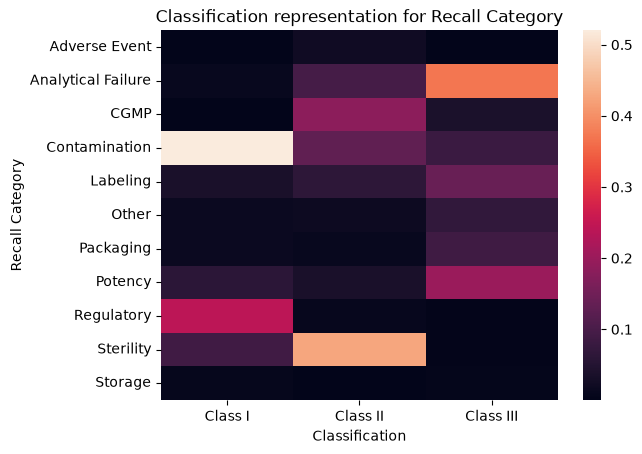

In [33]:
grafico = sns.heatmap(data = tabella)
grafico.set(
    title = 'Classification representation for Recall Category',
    xlabel = 'Classification',
    ylabel = 'Recall Category'
)
plt.show()

**Insights**
 - In Class I the most representative cause in contamination (~50%), this cause can be very dangerous for the population health. Drug contamination can be:
    - Chemical: other chemical substances can contaminate the drug and lead to toxicity and lack of efficacy
    - Biological: microorganism in drug can modify the safety and efficacy of the drug by metabolic processes.
 - Regulatory (not approved drugs) is a Class I significative risk
 - Analytical Failure and Adverse Event are present in Class III, this can be explained:
    - Adverse Event are not very dangerous for people because the drug in previously tested
    - Analytical Failure are problems that does not affect the drug efficacy. 

## KPI 2 - Regulatory response timing
### Days between recall_initiation_date and center_classification_date
Identifying the timing between the recall initiation and the classification date, can determine the efficiency and the attribution rapidity of the class to the drug recall. 

Record event_id 35255 has a gap of 2,447 days between the recall initiation 
and the FDA classification (2006-2012). This is attributed to a wrong data entry — 
no regulatory process justifies 7 years of pending classification.

Records with classification time > 365 days are excluded as outliers (N = X, 1.4% 
of the dataset). A 365-day threshold represents a reasonable upper bound for a 
regulatory classification process under normal operating conditions.

In [34]:
df_clean['recall_classification_days'] = (df_clean['center_classification_date'] - df_clean['recall_initiation_date']).dt.days
df_filtrato = df_clean.query('recall_classification_days >= 0 and recall_classification_days <= 365')


In [35]:
excluded = df_clean[df_clean['recall_classification_days']>365].shape[0]
print(excluded)
print(f'{excluded/len(df_clean)*100:.1f}%')

255
1.4%


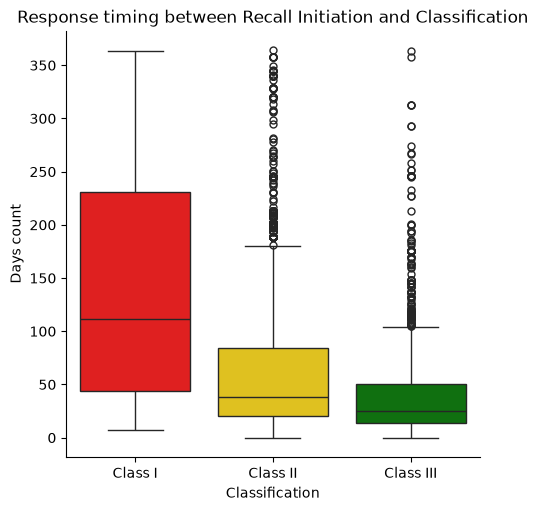

In [36]:
ordine = ['Class I', 'Class II', 'Class III']
colors = {
    'Class I': 'red',
    'Class II': 'gold',
    'Class III': 'green'
}
risposta = sns.catplot(
    kind = 'box',
    data = df_filtrato, 
    x = 'classification', 
    y = 'recall_classification_days',
    estimator = 'median',
    order = ordine,
    hue = 'classification',
    legend = False,
    palette = colors
)
risposta.set(title = 'Response timing between Recall Initiation and Classification', 
             xlabel = 'Classification', 
             ylabel = 'Days count')
plt.show()

**Insights**

Class I recalls have bigger median timing and variability than Class II and Class III. This represents the procedural complexity of high risk cases - more documents, legal ascertainment and FDA coordination that are required before the official classification.

In [37]:
# Estraggo dati in base alla colonna d'interesse
df_voluntary = df_filtrato.copy()
df_voluntary['voluntary_mandated'] = df_voluntary['voluntary_mandated'].str.lower()
df_voluntary['voluntary_mandated'].value_counts()

voluntary_mandated
voluntary: firm initiated    17390
fda mandated                    29
Name: count, dtype: int64

For this analysis are considered the Voluntary Mandated data because the FDA Mandated are only represented by 29 records and are all attributed to Class II

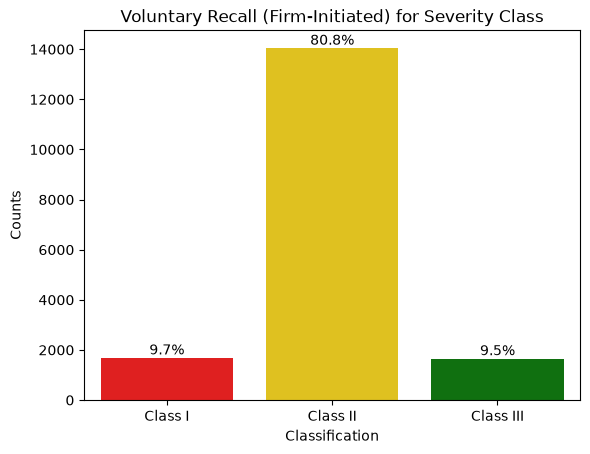

In [38]:
# Estraggo dati in base alla colonna d'interesse
voluntary = df_voluntary[df_voluntary['voluntary_mandated'].str.lower() == 'voluntary: firm initiated']

ordine = ['Class I', 'Class II', 'Class III']

colors = {
    'Class I': 'red',
    'Class II': 'gold',
    'Class III': 'green'
}

ax = sns.countplot(
    data=voluntary,
    x='classification',
    order=ordine,
    hue = 'classification',
    palette=colors
)

# Totale osservazioni
tot = len(voluntary)

# Etichette percentuali
for container in ax.containers:
    labels = [
        f'{100 * bar.get_height() / tot:.1f}%'
        if bar.get_height() > 0 else ''
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=0)

ax.set( title = 'Voluntary Recall (Firm-Initiated) for Severity Class',
       xlabel = 'Classification',
       ylabel = 'Counts'
       )

plt.show()

#### Voluntary Recall Analysis for Severity Class

The 99.8% of the pharmaceutical recalls are firm-initiated. 
This can suggest that the post-commercialization pharmacovigilance are efficient in the industries.
It's not possible to exclude the informal push acted by the FDA before the official mandatory.

**Insights**
- 80.8% of the Voluntary Recalls are form the Class II - The pharmaceutical industries are prone to initiate the recall of intermediate severity. The Class I recalls requires more complex legal and regulatory processes that can slow down the autonomous initiative.
- Class I and Class III have analogous percentage (9.7% vs 9.5%) in voluntary recalls. A voluntary mandated cross analysis with Class can be necessary to interpreting this similarity.

## KPI 3 - Temporal Trend
### Annual recalls Trend (2006-2026)
Distribution of recalls by year and Class for monitoring the drugs recalls each year.

Year extraction from 'recall_initiation_date' to identifying the yearly initiated recall

In [39]:
df_temporal = df_clean.copy()
df_temporal['year'] = pd.to_datetime(df_temporal['recall_initiation_date']).dt.year
df_temporal['year'] = df_temporal['year'].astype(int)
df_temporal.head()

,status,city,state,country,classification,product_type,event_id,recalling_firm,voluntary_mandated,initial_firm_notification,...,reason_for_recall,recall_initiation_date,center_classification_date,termination_date,report_date,code_info,brand_name,recall_category,recall_classification_days,year
0,Terminated,Peoria,IL,United States,Class II,Drugs,72241,"Kalman Health & Wellness, Inc. dba Essential W...",Voluntary: Firm initiated,Letter,...,Lack of Assurance of Sterility: A recall of a...,2015-09-03,2015-11-17,2017-12-29,2015-11-25,"Lot #: 072915, Exp 10/29/2015",NaN,Sterility,75,2015
1,Ongoing,San Juan Del Rio,NaN,Mexico,Class II,Drugs,86162,Albek De Mexico S.A. De C.V.,Voluntary: Firm initiated,Press Release,...,CGMP Deviations: Next Advanced Antibacterial H...,2020-07-30,2020-11-17,NaT,2020-11-25,1931102AL,NaN,CGMP,110,2020
2,Ongoing,Exton,PA,United States,Class II,Drugs,97808,ProRx LLC,Voluntary: Firm initiated,Letter,...,Lack of Assurance of Sterility,2025-10-15,2025-10-27,NaT,2025-11-05,"Lot, Best Use Date (BUD): Lot PRORX050925-1, ...",NaN,Sterility,12,2025
3,Terminated,Parsippany,NJ,United States,Class II,Drugs,85712,Teva Pharmaceuticals USA,Voluntary: Firm initiated,Letter,...,Some bottles may contain mixed strengths of th...,2020-05-22,2020-06-04,2021-05-25,2020-06-10,"Lot #: 42614718, Exp. date 02/2021","DEXTROAMPHETAMINE SACCHARATE, AMPHETAMINE ASPA...",Potency,13,2020
4,Terminated,Allegan,MI,United States,Class II,Drugs,88905,Perrigo Company PLC,Voluntary: Firm initiated,Letter,...,CGMP Deviations: Products were manufactured wi...,2021-10-26,2022-02-23,2023-09-29,2022-03-02,"Batch: 1BK0964, Exp 01/31/2023",EQUALINE NASAL,Contamination,120,2021


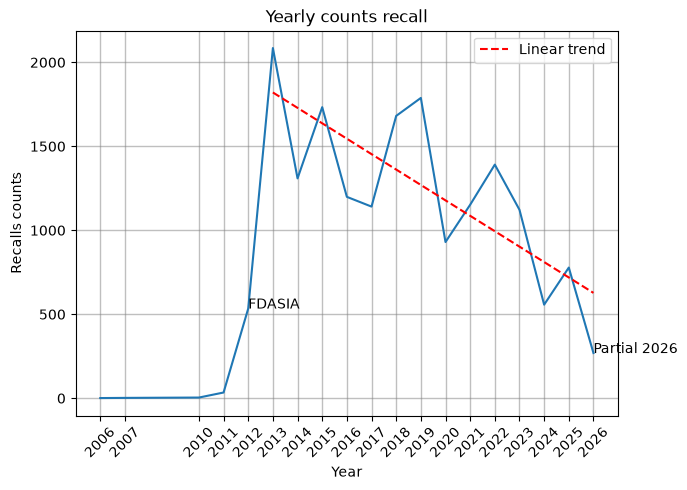

In [40]:
counts = df_temporal['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize = (7, 5))

ax.plot(counts.index, counts.values)
ax.set_title('Yearly counts recall')
ax.set_xlabel('Year')
ax.set_ylabel('Recalls counts')
ax.set_xticks([i for i in counts.index])
ax.tick_params(axis='x',labelrotation = 45)
ax.grid(color = 'gray', linestyle= '-', linewidth=1, alpha = 0.5)
ax.annotate('FDASIA', (2012, 534))
ax.annotate('Partial 2026',(2026, 269))

# Trend after FDASIA (2012)
trend = counts[counts.index>2012]
trend_coeff = np.polyfit(trend.index, trend.values, deg = 1)
trend_line = np.poly1d(trend_coeff)

ax.plot(trend.index, trend_line(trend.index), color='red', linestyle='--', label='Linear trend')
ax.legend()

In [41]:
print(f'Trend: {trend_coeff[0]:.1f} recalls/year')

Trend: -91.8 recalls/year


The analysis of annual recall counts reveals three distinct phases:

- **2006-2011:** Very low recall counts — the FDA enforcement database 
  was not yet fully operational for the reporting period.
- **2012-2013:** Sharp increase following the introduction of the Food and Drug 
  Administration Safety and Innovation Act (FDASIA, 2012 July 9), which strengthened 
  drug safety controls and reporting requirements.
- **2013-2026:** High variability with no clear short-term pattern. A linear 
  regression on the 2013-2026 period confirms a long-term decreasing trend 
  of - 91,8 recalls/year, suggesting a progressive improvement in pharmaceutical manufacturing quality following FDASIA implementation.

**Note:** 2026 data is partial (January–June only) and is not representative 
of the full year.

The year-on-year variability cannot be fully explained with the available data. 
A cross-analysis with FDA inspection records or enforcement actions would be 
required to identify the underlying causes.

### Annual Distribution by Classification (2012-2026)

The data volumes for the period from 2006 to 2012 are too low to be representative; therefore, we calculate the distribution of drug recalls by classification starting from 2012.



In [42]:
df_temp = df_temporal[df_temporal['year']>2012]

In [43]:
# Classification for Year
class_year = pd.crosstab(df_temp['year'], df_temp['classification'], normalize = 'index')


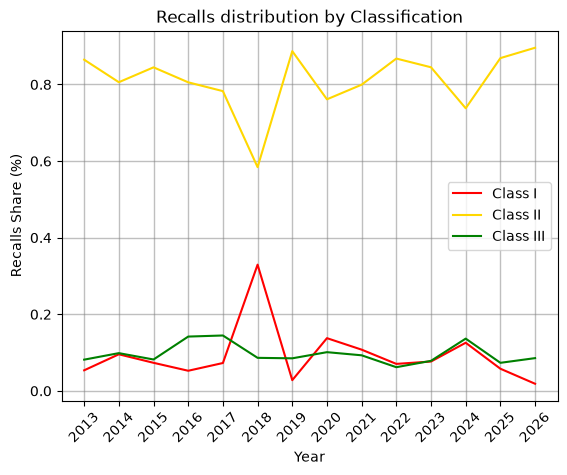

In [44]:
fig, ax = plt.subplots()

ax.plot(
    class_year.index,
    class_year["Class I"],
    label="Class I",
    color="red"
)

ax.plot(
    class_year.index,
    class_year["Class II"],
    label="Class II",
    color="gold"
)

ax.plot(
    class_year.index,
    class_year["Class III"],
    label="Class III",
    color="green"
)

ax.legend()
ax.set_xticks([i for i in class_year.index])
ax.tick_params(axis = 'x', labelrotation = 45 )
ax.set_xlabel('Year')
ax.set_ylabel('Recalls Share (%)')
ax.set_title('Recalls distribution by Classification')
ax.grid(color = 'gray', linestyle= '-', linewidth=1, alpha = 0.5)

**Insights**

- Class II accounts for ~80% of recalls throughout the period, consistent 
  with the KPI 1 distribution analysis.
- The Class I spike in 2018 (~33%) is attributable to the ARB contamination 
  crisis (valsartan, losartan, irbesartan) — multiple manufacturers recalled 
  products contaminated with NDMA, a potential carcinogen found in the API 
  synthesis process.
- Class III remains consistently low, reflecting its lower severity and 
  confirming the pattern observed in the voluntary recall analysis.

## KPI 4 - Top Recalling Firm
### Major recall industries
Distribution of the drug recalls by the pharmaceutical industries divided in compounding and manufacturing, based on the industrial activities operated. 

In [45]:
def firm_type(testo):
    t = testo.lower()
    if any(parola in t for parola in ['compounding', 'pharmacy', 'rx', 'admixture']):
        return 'compounding'
    else:
        return 'manufacturer'

df_clean['firm_type'] = df_clean['recalling_firm'].apply(firm_type)



**Methodological Note — Firm Classification**
Compounding pharmacies are identified by keywords in the firm name 
('compounding', 'pharmacy', 'apothecary', 'rx', 'admixture').
This approach may misclassify firms whose names are not descriptive 
(e.g. Pharmedium Services LLC, Aidapak Services LLC).
A manual verification of all firm names would be required for a complete classification.

#### Pharmaceutical compounding industries
Extract the top 10 industries with the major volume of recalls and divide the recalls by classification

In [46]:
# Extract the compounding industries
df_compounding = df_clean[df_clean['firm_type'] == 'compounding']
# Top 10 compounding industries
top_compounding = df_compounding['recalling_firm'].value_counts().sort_values(ascending=False).head(10)
# List the industries names
top_10_industries = [name for name in top_compounding.index]
# Filtering by the industry name in top 10
df_top_compound = df_compounding[df_compounding['recalling_firm'].isin(top_10_industries)]
# Crosstab with classification
top_compounding_class = pd.crosstab(df_top_compound['recalling_firm'], df_top_compound['classification'])


Text(0.5, 0, 'Recalling count by Classification')

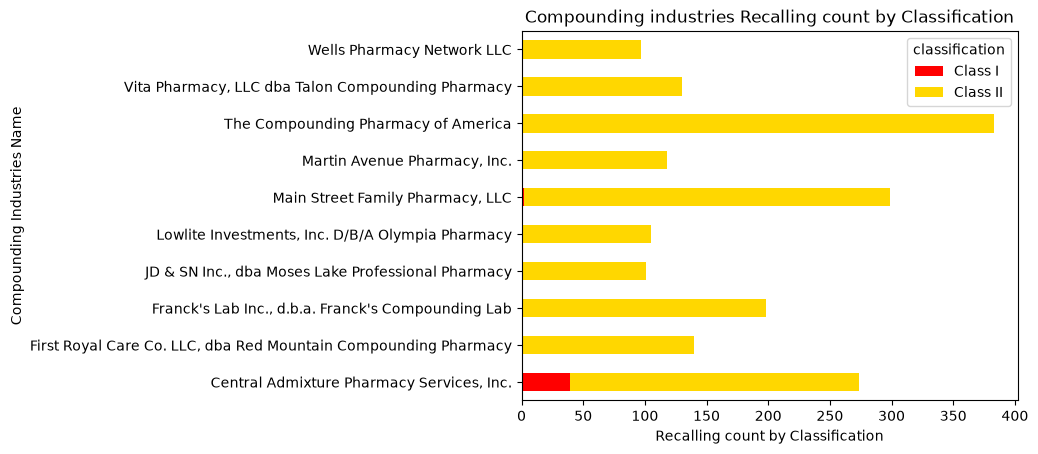

In [47]:
colors = {
    'Class I': 'red',
    'Class II': 'gold',
    'Class III': 'green'
}

barh = top_compounding_class.plot(
    kind = 'barh',
    stacked = True,
    color= colors,
)

barh.set_title('Compounding industries Recalling count by Classification')
barh.set_ylabel('Compounding Industries Name')
barh.set_xlabel('Recalling count by Classification')

**Insights**

Compounding pharmacies prepare drugs based on individual prescriptions, rather 
than producing FDA-approved drugs through standardized industrial processes. 
This involves the preparation cycle more directly, which explains why their 
recalls are concentrated in Class I and Class II — categories dominated by 
Sterility, Contamination, and Regulatory causes.

Compounded products are often sterile preparations (injectables, ophthalmics) 
used in the most critical clinical contexts. This explains why Sterility and 
Contamination dominate, leading to Class I/II recalls rather than the minor 
issues (labeling, packaging) typically seen in Class III recalls from 
industrial manufacturers.

Notably, none of the top 10 compounding pharmacies show any Class III recalls — 
suggesting that quality issues in compounded sterile preparations tend to carry 
inherently higher clinical risk.

In [48]:
# Extract the manufacturer industries
df_manufacturer = df_clean[df_clean['firm_type'] == 'manufacturer']
escludi = ['King Bio Inc.', 'Attix Pharmaceuticals', 'Aidapak Services, LLC']
df_manufacturer_filtered = df_manufacturer[~df_manufacturer['recalling_firm'].isin(escludi)]
# Top 10 manufacturer industries
top_manufacturer = df_manufacturer_filtered['recalling_firm'].value_counts().sort_values(ascending=False).head(10)
# List the industries names
manufacturer_top_10_industries = [name for name in top_manufacturer.index]
# Filtering by the industry name in top 10
df_top_manufacturer = df_manufacturer_filtered[df_manufacturer_filtered['recalling_firm'].isin(manufacturer_top_10_industries)]
# Crosstab with classification
top_manufacturer_class = pd.crosstab(df_top_manufacturer['recalling_firm'], df_top_manufacturer['classification'])

man_order = top_manufacturer_class.sort_values(by = ['Class I', 'Class II', 'Class III'], ascending = [True, True, True])

**Note:** Three firms are excluded from this analysis due to recall volumes 
dominated by a single concentrated event rather than recurring issues over time:
- King Bio Inc.: 465 recalls, single 2018 microbial contamination event.
- Attix Pharmaceuticals: 463 of ~470 recalls from a single 2012-2015 penicillin 
  cross-contamination event.
- Aidapak Services, LLC: 538 recalls, all concentrated in 2013, suggesting a 
  systemic labeling process failure within a single year rather than chronic, 
  diversified issues.

This refined exclusion criterion accounts for both root-cause concentration 
and temporal concentration of recall events.

Text(0.5, 0, 'Recalling count by Classification')

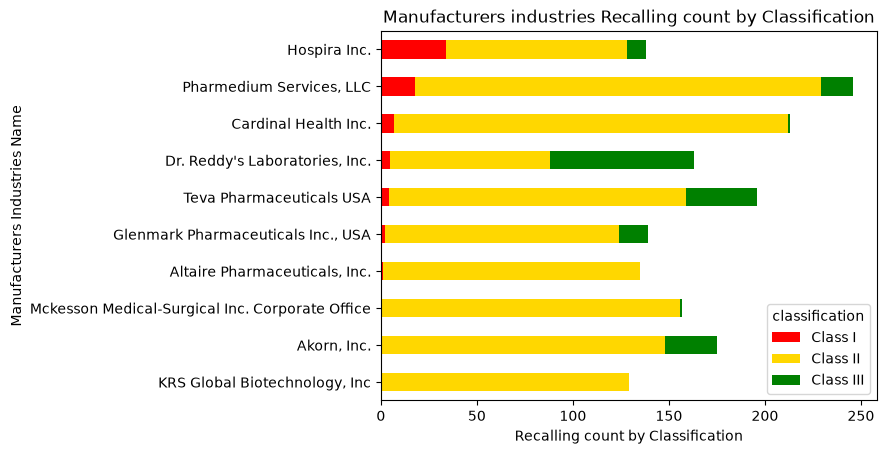

In [49]:
colors = {
    'Class I': 'red',
    'Class II': 'gold',
    'Class III': 'green'
}

barh = man_order.plot(
    kind = 'barh',
    stacked = True,
    color= colors
)

barh.set_title('Manufacturers industries Recalling count by Classification')
barh.set_ylabel('Manufacturers Industries Name')
barh.set_xlabel('Recalling count by Classification')


**Insights**

Four firms in the top 10 — Hospira Inc., Dr. Reddy's Laboratories, Teva 
Pharmaceuticals USA, and Akorn, Inc. — show recalls distributed across all 
three severity classes, while the remaining firms show recalls concentrated 
almost exclusively in Class II.

This pattern is more likely explained by production volume and portfolio 
diversity than by differences in quality control standards: large 
manufacturers with broad, high-volume drug portfolios are statistically more 
likely to encounter the full spectrum of recall causes (sterility, potency, 
contamination, labeling) across different batches and products over time. 
Firms with narrower portfolios or more homogeneous processes may show recalls 
concentrated in a single severity class.

This interpretation is based on classification data alone and would require 
further analysis (e.g. portfolio size, production volume, product type) to 
be confirmed.